In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

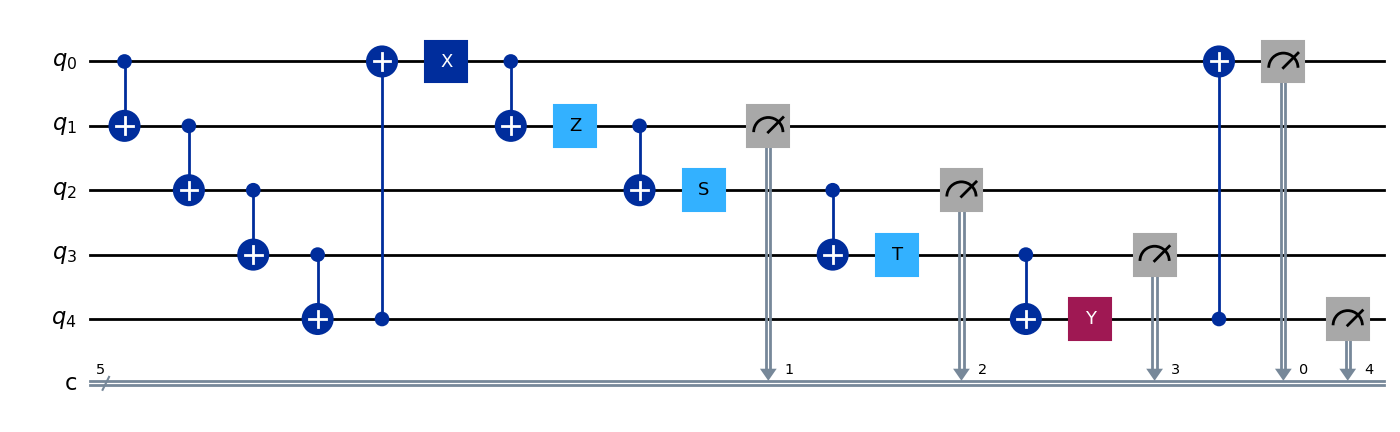

In [2]:
qc = QuantumCircuit(5, 5)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [18]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [19]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.120625
Errors for each run: [0.123046875, 0.115234375, 0.12109375, 0.1279296875, 0.1279296875, 0.1171875, 0.119140625, 0.1142578125, 0.123046875, 0.1142578125, 0.138671875, 0.126953125, 0.12890625, 0.115234375, 0.107421875, 0.1298828125, 0.1162109375, 0.125, 0.1298828125, 0.138671875, 0.1142578125, 0.1201171875, 0.1123046875, 0.130859375, 0.1220703125, 0.107421875, 0.1142578125, 0.1279296875, 0.1318359375, 0.111328125, 0.1044921875, 0.109375, 0.126953125, 0.1123046875, 0.11328125, 0.1298828125, 0.1083984375, 0.1171875, 0.1357421875, 0.130859375, 0.1142578125, 0.1162109375, 0.1220703125, 0.126953125, 0.1220703125, 0.10546875, 0.1162109375, 0.1318359375, 0.1162109375, 0.119140625]


In [1]:
import numpy as np
errors = [0.123046875, 0.115234375, 0.12109375, 0.1279296875, 0.1279296875, 0.1171875, 0.119140625, 0.1142578125, 0.123046875, 0.1142578125, 0.138671875, 0.126953125, 0.12890625, 0.115234375, 0.107421875, 0.1298828125, 0.1162109375, 0.125, 0.1298828125, 0.138671875, 0.1142578125, 0.1201171875, 0.1123046875, 0.130859375, 0.1220703125, 0.107421875, 0.1142578125, 0.1279296875, 0.1318359375, 0.111328125, 0.1044921875, 0.109375, 0.126953125, 0.1123046875, 0.11328125, 0.1298828125, 0.1083984375, 0.1171875, 0.1357421875, 0.130859375, 0.1142578125, 0.1162109375, 0.1220703125, 0.126953125, 0.1220703125, 0.10546875, 0.1162109375, 0.1318359375, 0.1162109375, 0.119140625]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.120625
Standard deviation of errors over 50 runs: 0.008653996914585552
0.1206 ± 0.0024 (95% CI)


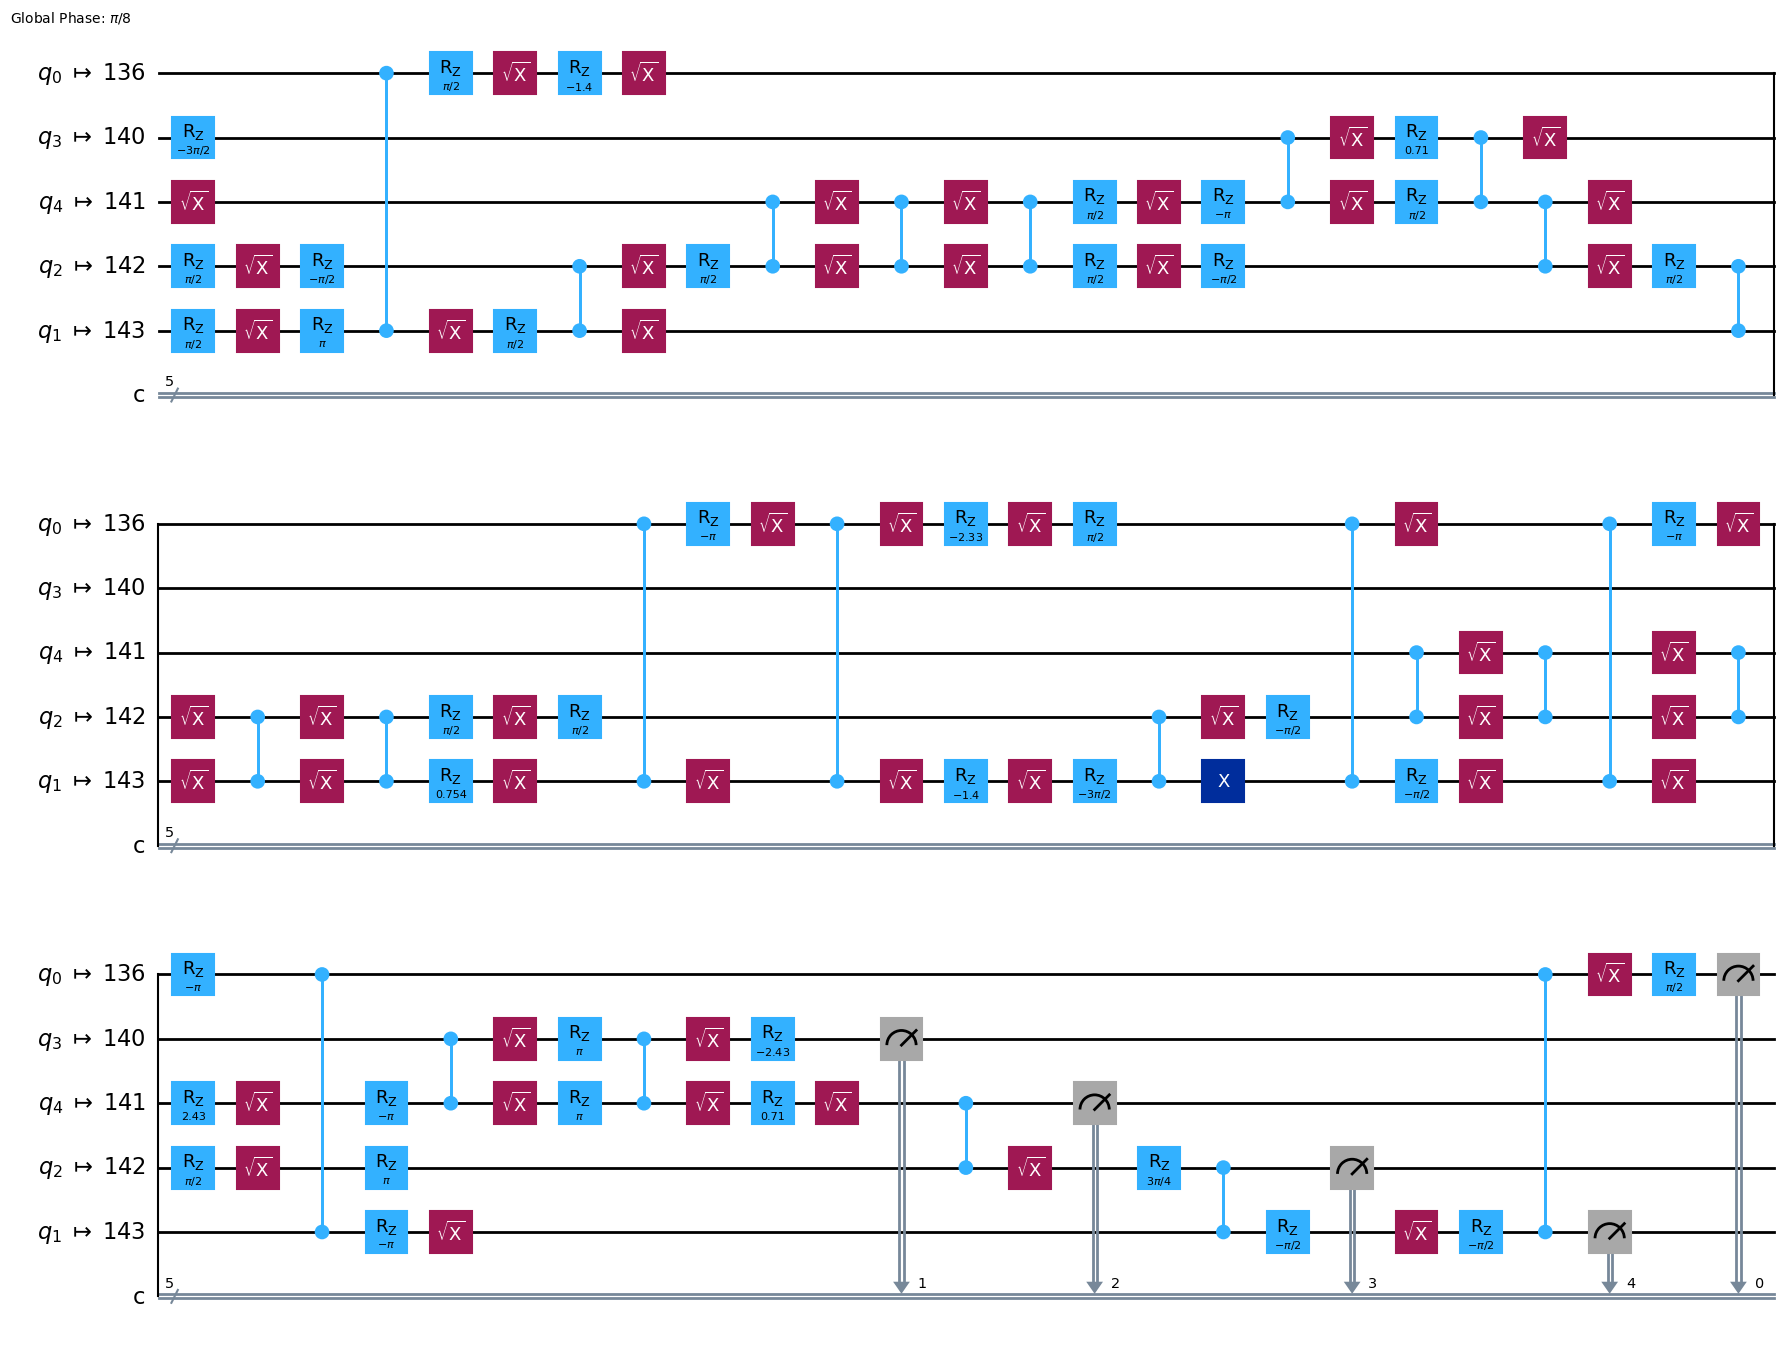

In [20]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [22]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.11216796875
Errors for each run: [0.1083984375, 0.1123046875, 0.1025390625, 0.1171875, 0.1025390625, 0.103515625, 0.1142578125, 0.12109375, 0.1220703125, 0.119140625, 0.1064453125, 0.1025390625, 0.1240234375, 0.1201171875, 0.1162109375, 0.1181640625, 0.126953125, 0.109375, 0.111328125, 0.11328125, 0.1064453125, 0.09765625, 0.099609375, 0.1259765625, 0.1181640625, 0.1064453125, 0.099609375, 0.107421875, 0.1103515625, 0.115234375, 0.0947265625, 0.12109375, 0.0927734375, 0.119140625, 0.1123046875, 0.1279296875, 0.1123046875, 0.1171875, 0.0986328125, 0.1123046875, 0.115234375, 0.1220703125, 0.1083984375, 0.1015625, 0.1298828125, 0.115234375, 0.1103515625, 0.123046875, 0.103515625, 0.1123046875]


In [2]:
import numpy as np
errors = [0.1083984375, 0.1123046875, 0.1025390625, 0.1171875, 0.1025390625, 0.103515625, 0.1142578125, 0.12109375, 0.1220703125, 0.119140625, 0.1064453125, 0.1025390625, 0.1240234375, 0.1201171875, 0.1162109375, 0.1181640625, 0.126953125, 0.109375, 0.111328125, 0.11328125, 0.1064453125, 0.09765625, 0.099609375, 0.1259765625, 0.1181640625, 0.1064453125, 0.099609375, 0.107421875, 0.1103515625, 0.115234375, 0.0947265625, 0.12109375, 0.0927734375, 0.119140625, 0.1123046875, 0.1279296875, 0.1123046875, 0.1171875, 0.0986328125, 0.1123046875, 0.115234375, 0.1220703125, 0.1083984375, 0.1015625, 0.1298828125, 0.115234375, 0.1103515625, 0.123046875, 0.103515625, 0.1123046875]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.11216796875
Standard deviation of errors over 50 runs: 0.008958884525345583
0.1122 ± 0.0025 (95% CI)


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [8]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 1


In [9]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [10]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7dsikm5nvhs73a637u0
Job ID: d7dsikrklj2c73f22ung
Job ID: d7dsil15a5qc73dq8pd0
Job ID: d7dsilh5a5qc73dq8peg
Job ID: d7dsilp5a5qc73dq8pg0
Job ID: d7dsilrklj2c73f22upg
Job ID: d7dsim3klj2c73f22uq0
Job ID: d7dsimbklj2c73f22urg
Job ID: d7dsimm5nvhs73a6382g
Job ID: d7dsimrklj2c73f22usg


In [11]:
job_ids = [
    "d7dsikm5nvhs73a637u0",
    "d7dsikrklj2c73f22ung",
    "d7dsil15a5qc73dq8pd0",
    "d7dsilh5a5qc73dq8peg",
    "d7dsilp5a5qc73dq8pg0",
    "d7dsilrklj2c73f22upg",
    "d7dsim3klj2c73f22uq0",
    "d7dsimbklj2c73f22urg",
    "d7dsimm5nvhs73a6382g",
    "d7dsimrklj2c73f22usg",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7dsikm5nvhs73a637u0: error = 0.2207
Job d7dsikrklj2c73f22ung: error = 0.2412
Job d7dsil15a5qc73dq8pd0: error = 0.2451
Job d7dsilh5a5qc73dq8peg: error = 0.2412
Job d7dsilp5a5qc73dq8pg0: error = 0.2334
Job d7dsilrklj2c73f22upg: error = 0.2441
Job d7dsim3klj2c73f22uq0: error = 0.2275
Job d7dsimbklj2c73f22urg: error = 0.2373
Job d7dsimm5nvhs73a6382g: error = 0.2090
Job d7dsimrklj2c73f22usg: error = 0.2500

Average error over runs: 0.2349609375


Running on: ibm_fez (156 qubits)


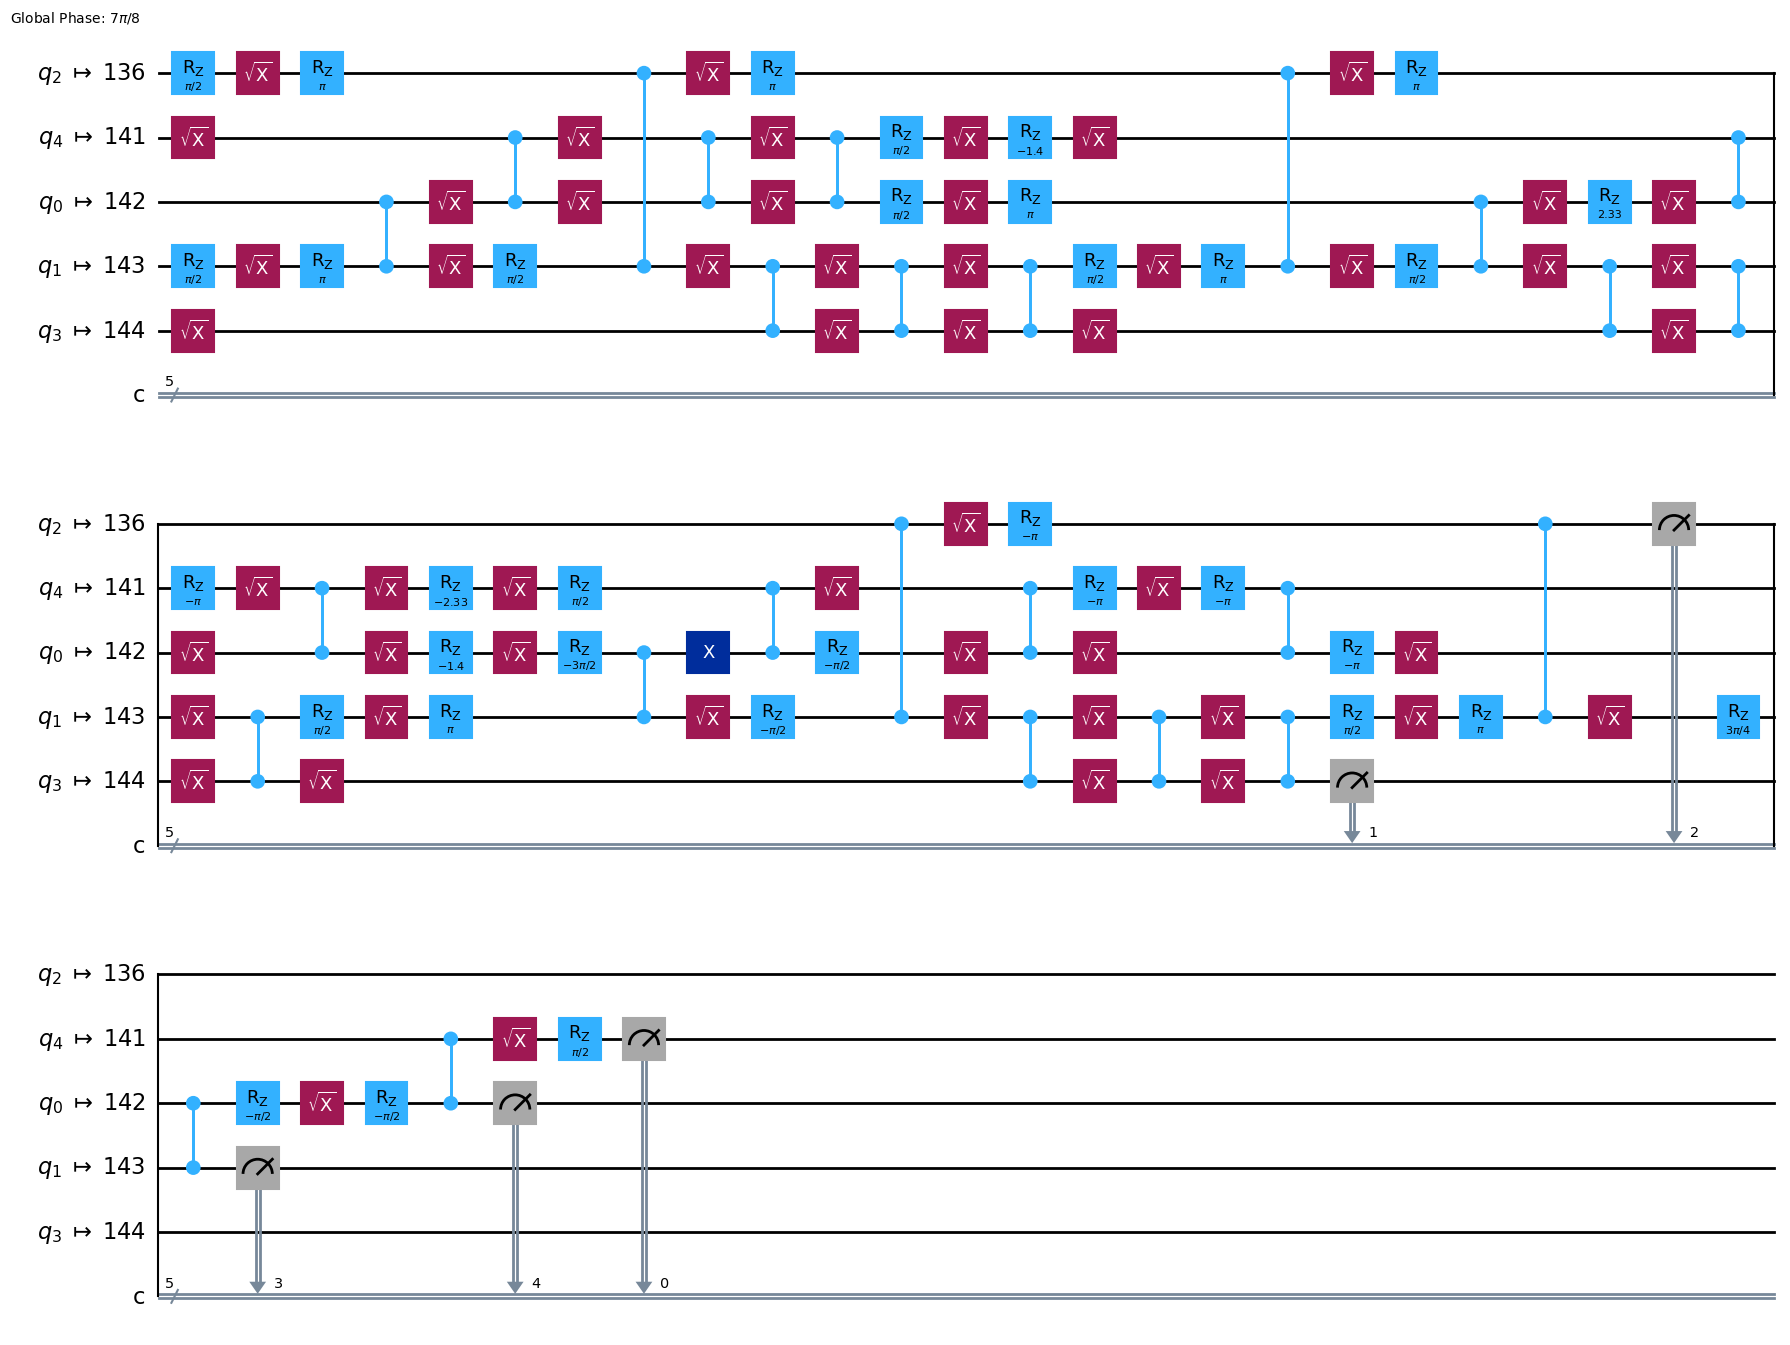

In [12]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [13]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7dsjru5nvhs73a639g0
Job ID: d7dsjs3klj2c73f2307g
Job ID: d7dsjsbklj2c73f2308g
Job ID: d7dsjsj0g7hs73dsb5e0
Job ID: d7dsjsrklj2c73f2309g
Job ID: d7dsjt3klj2c73f230b0
Job ID: d7dsjtb0g7hs73dsb5fg
Job ID: d7dsjt95a5qc73dq8qs0
Job ID: d7dsjtjklj2c73f230d0
Job ID: d7dsjtr0g7hs73dsb5h0


In [14]:
job_ids = [
    "d7dsjru5nvhs73a639g0",
    "d7dsjs3klj2c73f2307g",
    "d7dsjsbklj2c73f2308g",
    "d7dsjsj0g7hs73dsb5e0",
    "d7dsjsrklj2c73f2309g",
    "d7dsjt3klj2c73f230b0",
    "d7dsjtb0g7hs73dsb5fg",
    "d7dsjt95a5qc73dq8qs0",
    "d7dsjtjklj2c73f230d0",
    "d7dsjtr0g7hs73dsb5h0",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7dsjru5nvhs73a639g0: error = 0.1309
Job d7dsjs3klj2c73f2307g: error = 0.1465
Job d7dsjsbklj2c73f2308g: error = 0.1504
Job d7dsjsj0g7hs73dsb5e0: error = 0.1279
Job d7dsjsrklj2c73f2309g: error = 0.1377
Job d7dsjt3klj2c73f230b0: error = 0.1406
Job d7dsjtb0g7hs73dsb5fg: error = 0.1416
Job d7dsjt95a5qc73dq8qs0: error = 0.1318
Job d7dsjtjklj2c73f230d0: error = 0.1172
Job d7dsjtr0g7hs73dsb5h0: error = 0.1191

Average error over runs: 0.134375


In [3]:
import time
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("Original circuit:")
print(f"No. of Gates: {qc.size()}")
print(f"Depth: {qc.depth()}\n")

print("My transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

from qiskit import transpile

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("\nQiskit transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:
No. of Gates: 20
Depth: 16

My transpiler:
No. of Gates: 246
Depth: 144
Transpilation time: 1.9409 seconds

Qiskit transpiler:
No. of Gates: 112
Depth: 61
Transpilation time: 0.0448 seconds
